In [1]:
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as f
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [2]:
X, y_continuous = make_regression(n_samples=1000,n_features=10, noise=10, random_state=42)

In [3]:
y = (y_continuous > np.median(y_continuous)).astype(int)

In [4]:
X_train, X_temp, y_train, y_temp = train_test_split(X,y,test_size = 0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size = 0.5, random_state = 42)

In [5]:
X_train = torch.tensor(X_train, dtype = torch.float32)
X_val = torch.tensor(X_val, dtype = torch.float32)
X_test = torch.tensor(X_test, dtype = torch.float32)
y_train = torch.tensor(y_train, dtype = torch.float32)
y_val = torch.tensor(y_val, dtype = torch.float32)
y_test = torch.tensor(y_test, dtype = torch.float32)

In [6]:
y_train = y_train.view(-1, 1)
y_val = y_val.view(-1, 1)
y_test = y_test.view(-1, 1)

In [7]:
class Logistic_Regression_model(nn.Module):
  def __init__(self,input_size,output_size):
    super(Logistic_Regression_model,self).__init__()
    self.fc = nn.Linear(input_size,output_size)
  def forward(self,x):
    out = self.fc(x)
    return out

In [8]:
model = Logistic_Regression_model(input_size = 10, output_size = 1)
loss_func = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model.parameters(), lr = 0.01)

In [9]:
epochs = 1000
training_loss =[]
validation_loss = []

In [10]:
for epoch in range(1000):
  model.train()
  y_pred = model(X_train)
  train_loss = loss_func(y_pred, y_train)
  optimizer.zero_grad()
  train_loss.backward()
  optimizer.step()
  training_loss.append(train_loss.item())

  model.eval()
  with torch.no_grad():
    val_pred = model(X_val)
    val_loss = loss_func(val_pred,y_val)
    validation_loss.append(val_loss.item())

    if (epoch + 1) % 100 == 0:
      print(
          f"Epoch [{epoch+1}/1000], "
          f"Train Loss: {train_loss.item():.4f}, "
          f"Val Loss: {val_loss.item():.4f}")

Epoch [100/1000], Train Loss: 0.6562, Val Loss: 0.6419
Epoch [200/1000], Train Loss: 0.5519, Val Loss: 0.5373
Epoch [300/1000], Train Loss: 0.4833, Val Loss: 0.4683
Epoch [400/1000], Train Loss: 0.4355, Val Loss: 0.4199
Epoch [500/1000], Train Loss: 0.4002, Val Loss: 0.3841
Epoch [600/1000], Train Loss: 0.3730, Val Loss: 0.3563
Epoch [700/1000], Train Loss: 0.3512, Val Loss: 0.3340
Epoch [800/1000], Train Loss: 0.3332, Val Loss: 0.3157
Epoch [900/1000], Train Loss: 0.3181, Val Loss: 0.3003
Epoch [1000/1000], Train Loss: 0.3052, Val Loss: 0.2872


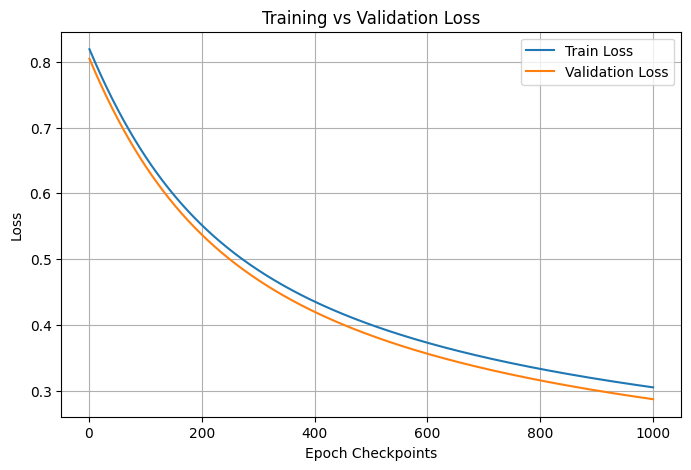

In [11]:
epochs = range(1, len(training_loss) + 1)

plt.figure(figsize=(8,5))

plt.plot(epochs, training_loss, label="Train Loss")
plt.plot(epochs, validation_loss, label="Validation Loss")

plt.xlabel("Epoch Checkpoints")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

In [12]:
model.eval()
with torch.no_grad():
  y_pred = model(X_test)
  test_loss = loss_func(y_pred,y_test)
  print(f"Test Loss: {test_loss.item():.4f}")

# Convert tensors to NumPy
y_test_np = y_test.cpu().numpy().ravel().astype(int)
probabilities = torch.sigmoid(y_pred)
predicted_classes = (probabilities >= 0.5).int()
y_pred_np = predicted_classes.cpu().numpy().ravel()

# Metrics
target_names = ["Class 0", "Class 1"]
print(classification_report(y_test_np, y_pred_np, target_names=target_names))

Test Loss: 0.2949
              precision    recall  f1-score   support

     Class 0       0.97      0.93      0.95        75
     Class 1       0.94      0.97      0.95        75

    accuracy                           0.95       150
   macro avg       0.95      0.95      0.95       150
weighted avg       0.95      0.95      0.95       150

